In [4]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from scipy import odr

import Methods as m
import importlib

importlib.reload(m)

def linear_0intercept(x, m):
    return m * x

def linear(p, x):
    return p[0]* x

def linear_wInt(p, x):
    return p[0]* x + p[1]

In [71]:
freq = 195
savename = "5s measurement Mar 23 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/NewFile' + str(freq) + 'kHz' + '.csv')
# time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/test_zoomed_vSweep.csv')

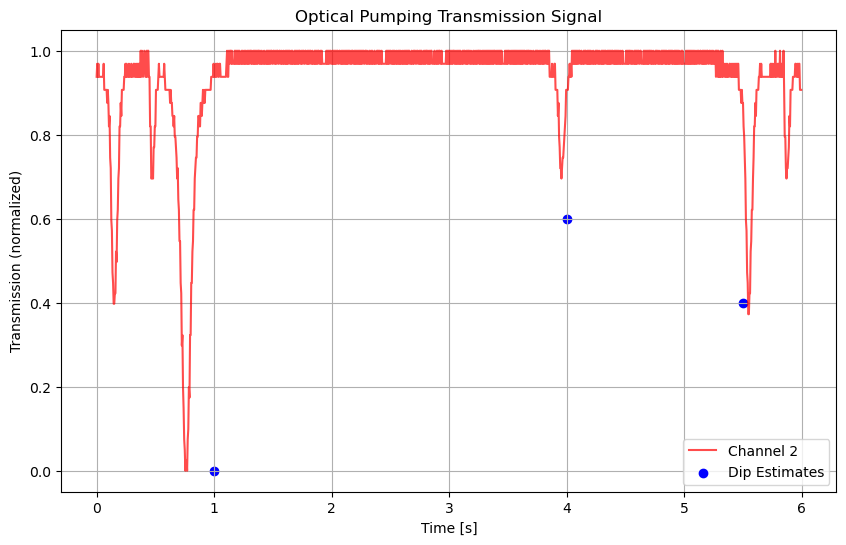

In [72]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1,4,5.5])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [73]:
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.triple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9700346328394706
h1 0.9832557820158981
g1 0.047643343399836766
x0_1 0.7621168724701683
h2 0.28212995154080106
g2 0.022865332855681868
x0_2 3.957132481196284
h3 0.6061332973277646
g3 0.027735453742788768
x0_3 5.550632276838768


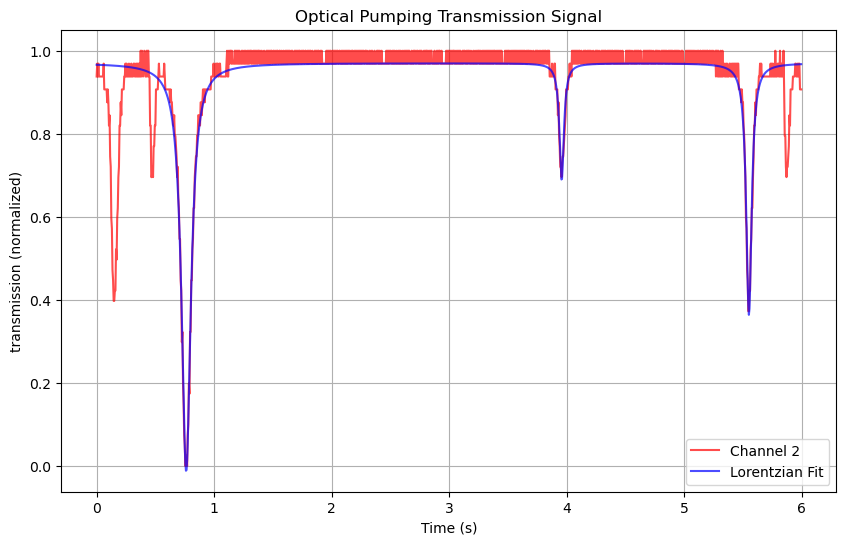

In [74]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.triple_lorentz, "fit to " + savename)

In [75]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0
x0_3_u = ufloat(popt[9], perr[9]) + t0

# 3. Handle indexing (indices must be integers, so we use n)
dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))

# print(y1[x0_3_index - numAvg : x0_3_index + numAvg])

# factor of 10 for measurements before Mar 9, from 10x probe
Rb_87 = (v_2 - v_1)
Rb_85 = (v_3 - v_1)

print(f"v_1: {v_1:.3e} V")

print(f"Rb87: {Rb_87:.3e} V")
print(f"Rb85: {Rb_85:.3e} V")

v_1: (2.910+/-0.056)e-01 V
Rb87: (4.494+/-0.086)e-01 V
Rb85: (6.722+/-0.106)e-01 V


In [76]:
filepath = 'models/VtoBcalibration.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)

In [ ]:
# Once that's all analyzed, do an autofit

In [7]:
df = pd.read_csv('./models/VtoBcalibration.csv', skiprows=2, skipfooter=0,
                 usecols=[0,2,3,4,5], names=['freq', 'Rb85', 'uRb85', 'Rb87', 'uRb87'], engine='python')

freq = df['freq'].values
Rb87 = df['Rb87'].values
Rb85 = df['Rb85'].values
uRb87 = df['uRb87'].values #/ 10 # division by 10 is just to see, not legit
uRb85 = df['uRb85'].values #/ 10 # division by 10 is just to see, not legit


In [8]:
popt, pcov = curve_fit(linear_0intercept, freq * 10**3, Rb87, sigma=uRb87, absolute_sigma=True)
perr87 = np.sqrt(np.diag(pcov))
m87 = ufloat(popt[0], perr87[0])

popt, pcov = curve_fit(linear_0intercept, freq * 10**3, Rb85, sigma=uRb85, absolute_sigma=True)
perr85 = np.sqrt(np.diag(pcov))
m85 = ufloat(popt[0], perr87[0])

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87.n * xFit * 10**3
Rb85Fit = m85.n * xFit * 10**3

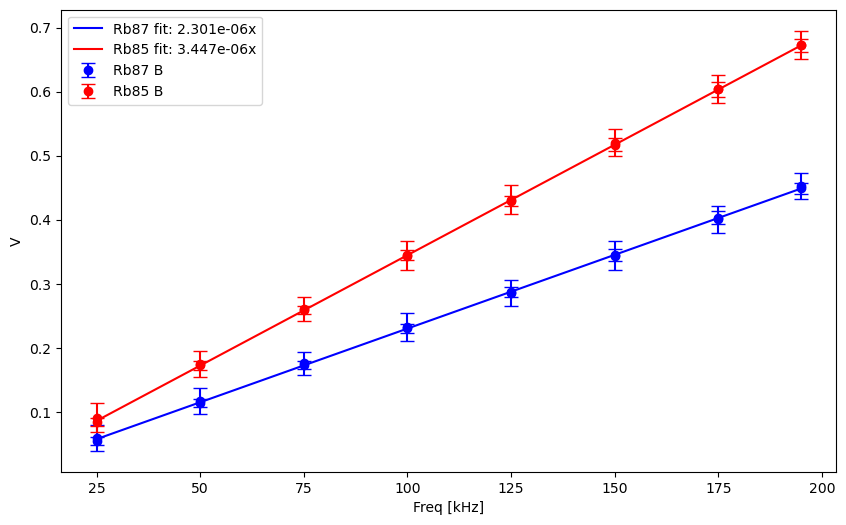

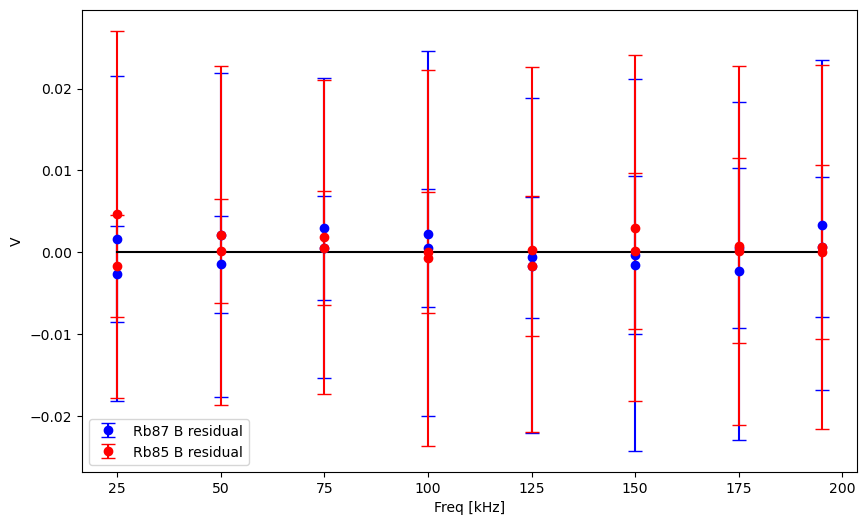

In [9]:
plt.figure(figsize=(10, 6))
plt.errorbar(freq, Rb87, yerr=uRb87, label='Rb87 B', capsize=5, fmt='o', color='blue')
plt.errorbar(freq, Rb85, yerr=uRb85, label='Rb85 B', capsize=5, fmt='o', color='red')

plt.plot(xFit, Rb87Fit, label=f'Rb87 fit: {m87.n:.3e}x', color='blue')
plt.plot(xFit, Rb85Fit, label=f'Rb85 fit: {m85.n:.3e}x', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('V')
plt.legend()
plt.savefig("./figures/gfactor linear range Mar 22", dpi=300)

plt.show()


Rb87Residual = Rb87 - m87.n * freq * 10**3
Rb85Residual = Rb85 - m85.n * freq * 10**3

plt.figure(figsize=(10, 6))
plt.errorbar(freq, Rb87Residual, yerr=uRb87,label='Rb87 B residual', capsize=5, fmt='o', color='blue')
plt.errorbar(freq, Rb85Residual, yerr=uRb85, label='Rb85 B residual', capsize=5, fmt='o', color='red')

plt.plot(xFit, np.zeros_like(xFit), color='black')
# plt.plot(xFit, np.zeros(xFit), label=f'Rb85 fit: {m85.n:.3e}x + {b85.n:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('V')
plt.legend()
plt.savefig("./figures/gfactor linear range residual Mar 22", dpi=300)

plt.show()

In [10]:
h = 6.626 * 10**(-34) # J s
muB = 9.2740 * 10**(-24) # J/T
gF87 = 0.4988 # (from gemini)
gF85 = 0.3337 # (from gemini)
muB = 9.2740 * 10**(-24) # J/T (from gemini)
muN = 5.05078 * 10**(-27) # J/T (from gemini)
gJ = 2.002331
gI = 6.6743 * 10**(-11) #m^3 /kgs^2

def muI(I):
    return gI * muN * I

# V = f * m, with m = ((2*I + 1) * h)/(gJ*muB + 2*(I+1)/I*muI) / VtoB
# -> VtoB = ((2*I + 1) * h)/(gJ*MuB + 2*(I+1)/I*muI) / m

I = 3/2
m87Expected = ((2*I + 1) * h)/(gJ*muB + 2*(I+1)/I*muI(I))
VtoB87 = m87Expected / m87

I = 5/2
m85Expected = ((2*I + 1) * h)/(gJ*muB + 2*(I+1)/I*muI(I))
VtoB85 = m85Expected / m85

print(f"VtoB from Rb87: {VtoB87:.5e}")
print(f"VtoB from Rb85: {VtoB85:.5e}")

VtoB = (VtoB87 + VtoB85)/2

print(f"VtoB averaged: {VtoB:.5e}")

VtoB from Rb87: (6.20272+/-0.05917)e-05
VtoB from Rb85: (6.21114+/-0.03956)e-05
VtoB averaged: (6.20693+/-0.03559)e-05


### Mar 23 calibration
Bshift to Vhoriz relationship with two points

In [34]:
freq = 195
V = ufloat(0.03395,0.0005) - ufloat(0.000124,0.000001) # Volts, from Mar23rd measurement

savename = "5s vHoriz measurement Mar 23 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/195_0p03395V.csv')


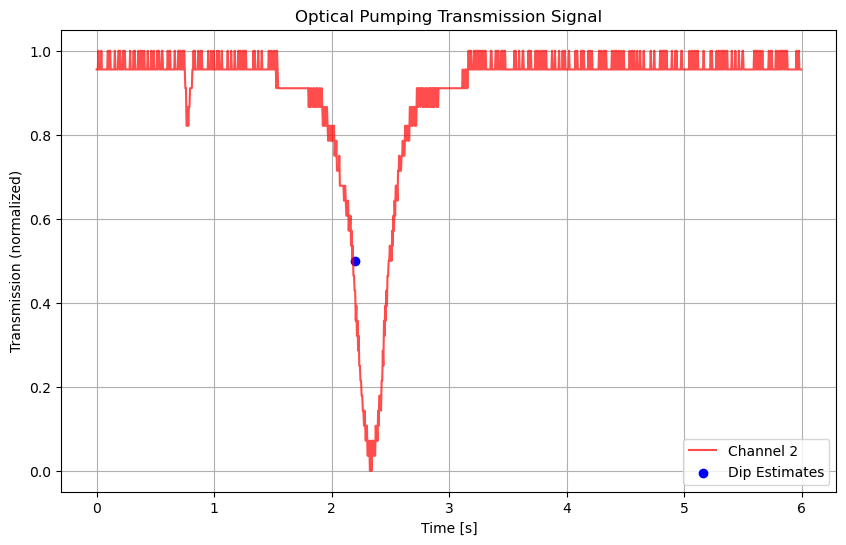

In [35]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0 =  2.2

plt.figure(figsize=(10, 6))
# Plot CH1 and CH2
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
# plt.plot(time, (y1-0.9)*10, label='Channel 1', color='blue', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

In [36]:
variables = ["A", "h", "g", "x0"]
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9722951958517747
h 0.9658785300655972
g 0.1530568599261866
x0 2.334184473359421


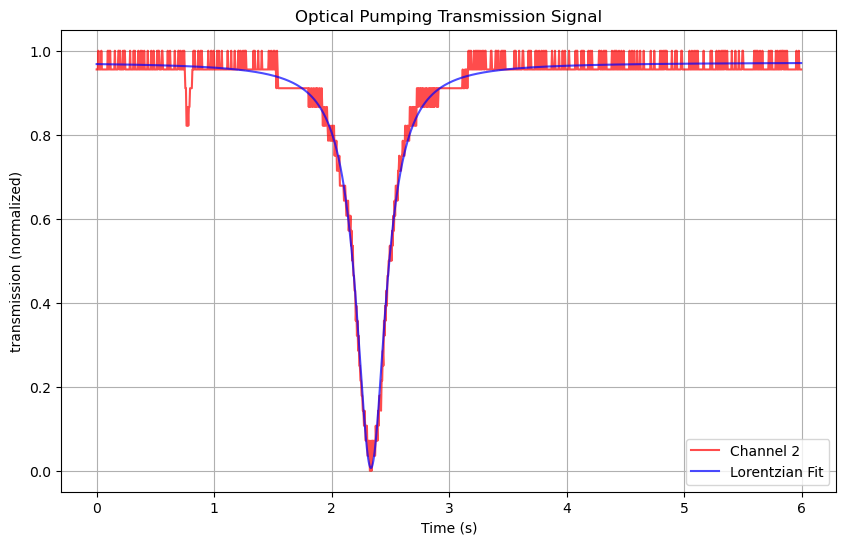

In [37]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)


In [38]:
x0_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x0_index = int(x0_u.n // dt)

numAvg = 10

v_0 = ufloat(np.mean(y1[x0_index - numAvg : x0_index + numAvg]),
             np.std(y1[x0_index - numAvg : x0_index + numAvg]))
print(y1[x0_index - numAvg : x0_index + numAvg])
print(f"v_0: {v_0:.2ue}")

[0.0216 0.0164 0.0232 0.016  0.0164 0.0256 0.0172 0.0212 0.022  0.0172
 0.0216 0.0172 0.0164 0.0256 0.0172 0.0232 0.0256 0.0168 0.0164 0.0212]
v_0: (1.99+/-0.34)e-02


In [31]:

time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/195_0p0000124V.csv')


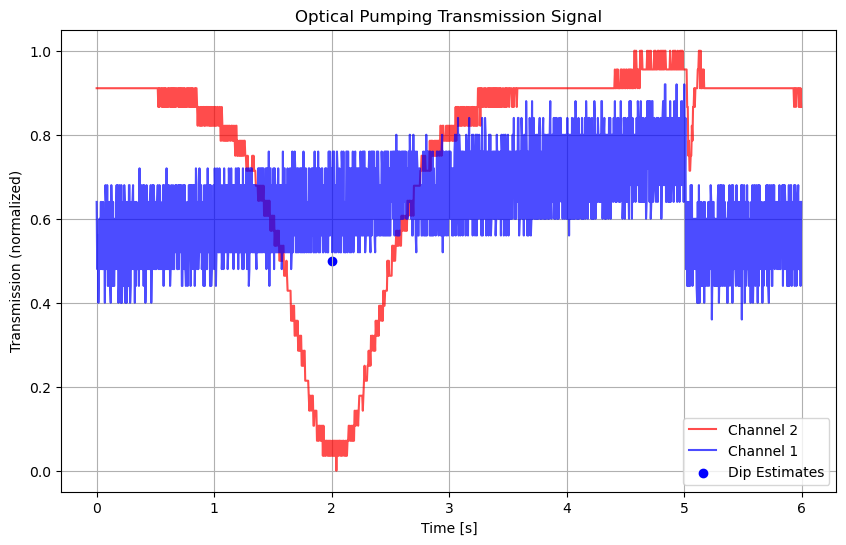

In [32]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0 =  2

plt.figure(figsize=(10, 6))
# Plot CH1 and CH2
# plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
# plt.plot(time, (y1-0.9)*10, label='Channel 1', color='blue', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

In [20]:
variables = ["A", "h", "g", "x0"]
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,15)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9581555012234017
h 0.950016104941764
g 0.43754581883383736
x0 2.0437590332843167


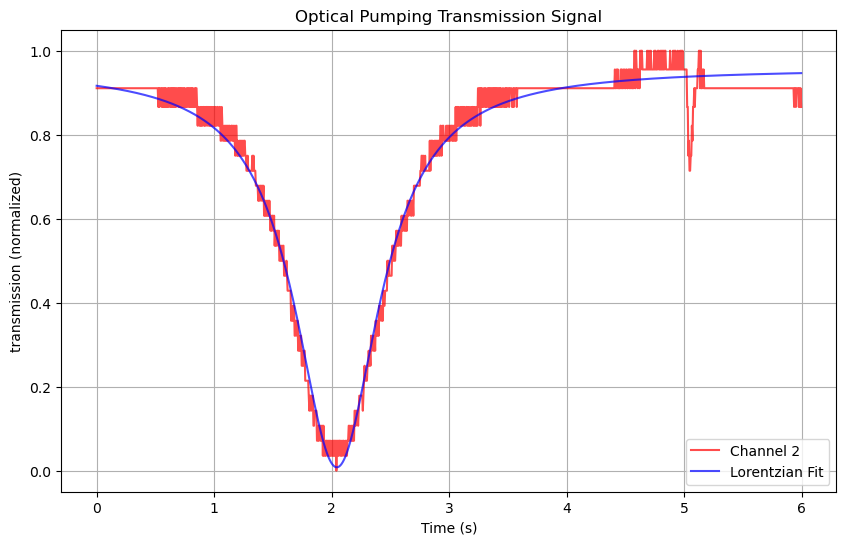

In [21]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)


In [33]:
x1_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x1_index = int(x1_u.n // dt)

numAvg = 10

v_1 = ufloat(np.mean(y1[x1_index - numAvg : x1_index + numAvg]),
             np.std(y1[x1_index - numAvg : x1_index + numAvg]))
print(y1[x1_index - numAvg : x1_index + numAvg])

print(f"v_1: {v_1:.2ue}")

[0.968 0.956 0.972 0.952 0.976 0.956 0.976 0.952 0.952 0.968 0.952 0.976
 0.972 0.956 0.952 0.972 0.968 0.952 0.952 0.976]
v_1: (9.63+/-0.10)e-01


In [26]:
# VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) /100) * 1.03360784475 # 1% uncertainty in the V measurement, adjusted with 1.075 term


print(f"VtoB: {VtoB:.2ue}")

print(f"deltaV: {v_1 - v_0:.2ue}")

deltaB = (v_1 - v_0) * VtoB
print(f"deltaB: {deltaB:.2ue}")

VhoriztoB = deltaB/V
print(f"VhoriztoB: {VhoriztoB:.5ue}")

VtoB: (6.207+/-0.036)e-05
deltaV: (9.43+/-0.11)e-01
deltaB: (5.853+/-0.074)e-05
VhoriztoB: (1.730183+/-0.033567)e-03


### March 25 linear relationship calibration
plot Vsweep over Vhoriz, to get the Vsweep to Vhoriz relationship


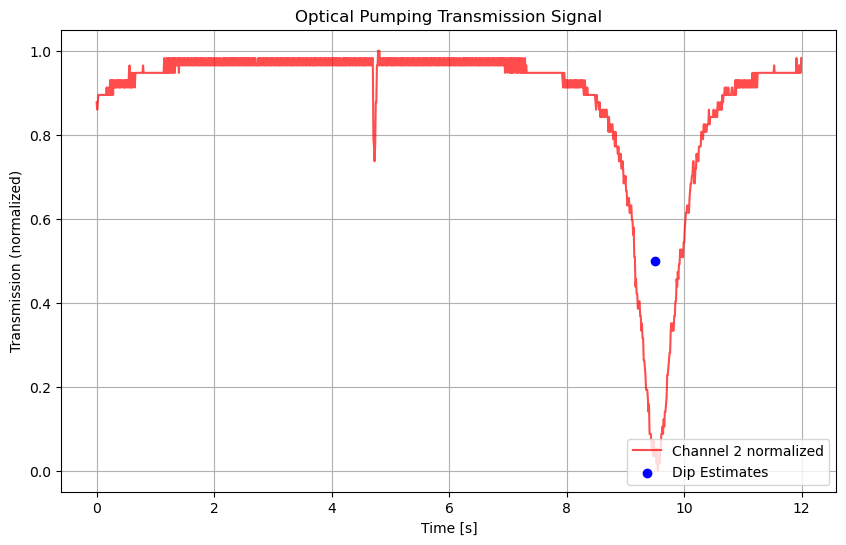

In [177]:
freq = 195
t0 = 0
x0 =  9.5
dV = ufloat(22.8,0.02) / 1000
savename = "5s measurement Mar 25 - " + str(freq) + 'kHz'
filename = "195kHz_22p8mV"


time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 25 measurement/' +filename+ '.csv')

nCut = (t0 // (time[1] - time[0])).astype(int)
time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]
plt.figure(figsize=(10, 6))
plt.plot(time, y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

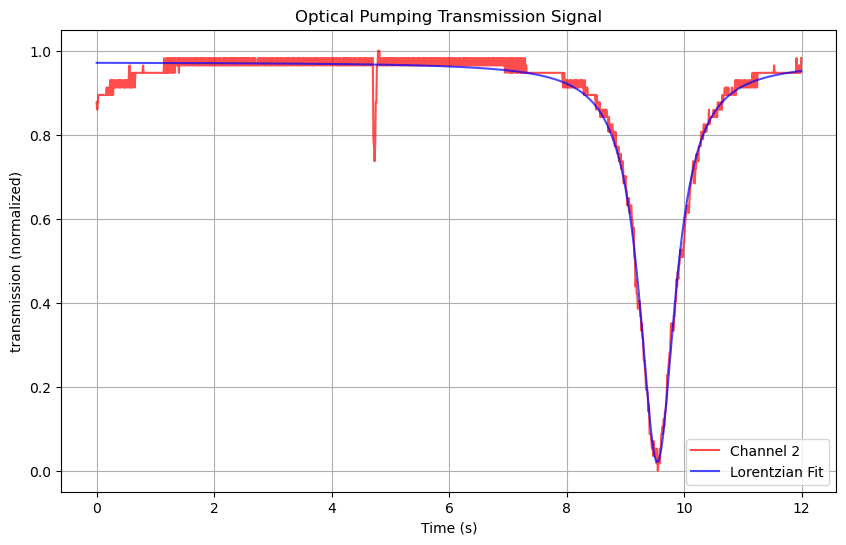

In [178]:
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [179]:
x0_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x0_index = int(x0_u.n // dt)

numAvg = 10

v_0 = ufloat(np.mean(y1[x0_index - numAvg : x0_index + numAvg]),
             np.std(y1[x0_index - numAvg : x0_index + numAvg]))
print(f"v_0: {v_0:.2ue}")

v_0: (1.095+/-0.027)e-01


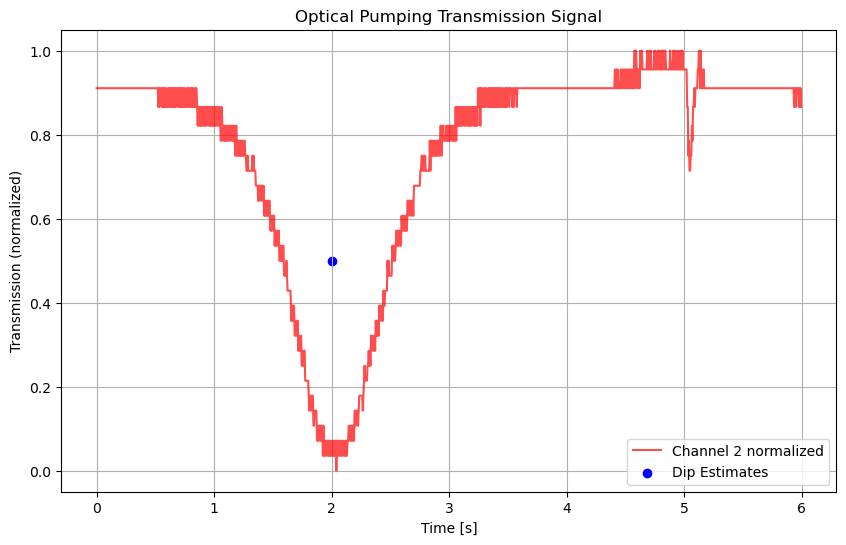

In [180]:
t0 = 0
x0 =  2
savename = "5s measurement Mar 25 - " + str(freq) + 'kHz'
filename = "195_0p0000124V"


time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/' +filename+ '.csv')

nCut = (t0 // (time[1] - time[0])).astype(int)
time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]
plt.figure(figsize=(10, 6))
plt.plot(time_cutFirst, y2_norm_cutFirst, label='Channel 2 normalized', color='red', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

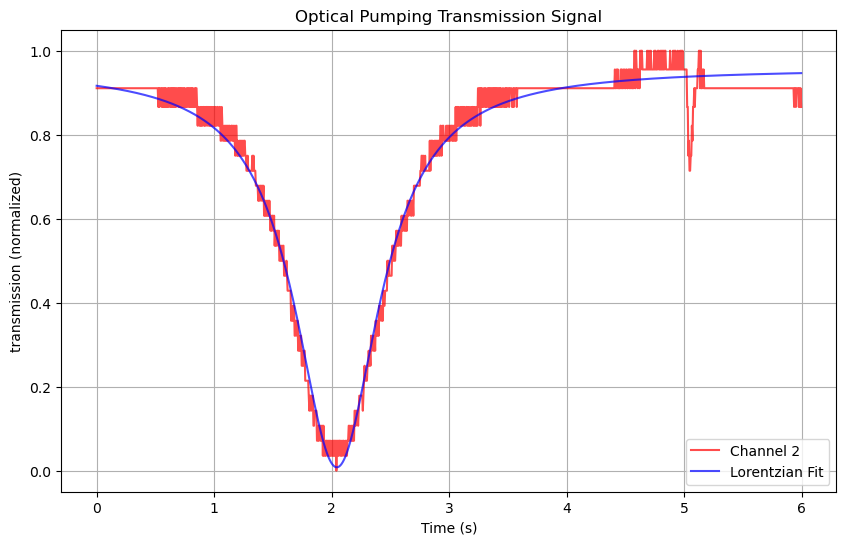

In [181]:
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [182]:
x1_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x1_index = int(x1_u.n // dt)

numAvg = 10

v_1 = ufloat(np.mean(y1[x1_index - numAvg : x1_index + numAvg]),
             np.std(y1[x1_index - numAvg : x1_index + numAvg]))
print(y1[x1_index - numAvg : x1_index + numAvg])

print(f"v_1: {v_1:.2ue}")
print(f"deltaV: {v_1 - v_0:.2ue}")

[0.968 0.956 0.972 0.952 0.976 0.956 0.976 0.952 0.952 0.968 0.952 0.976
 0.972 0.956 0.952 0.972 0.968 0.952 0.952 0.976]
v_1: (9.63+/-0.10)e-01
deltaV: (8.53+/-0.10)e-01


In [183]:
m.append_to_Vcalibration((v_1 - v_0),dV,"models/VtoVcalibration.csv")

Attempting to write to models/VtoVcalibration.csv...
write completed
function returning


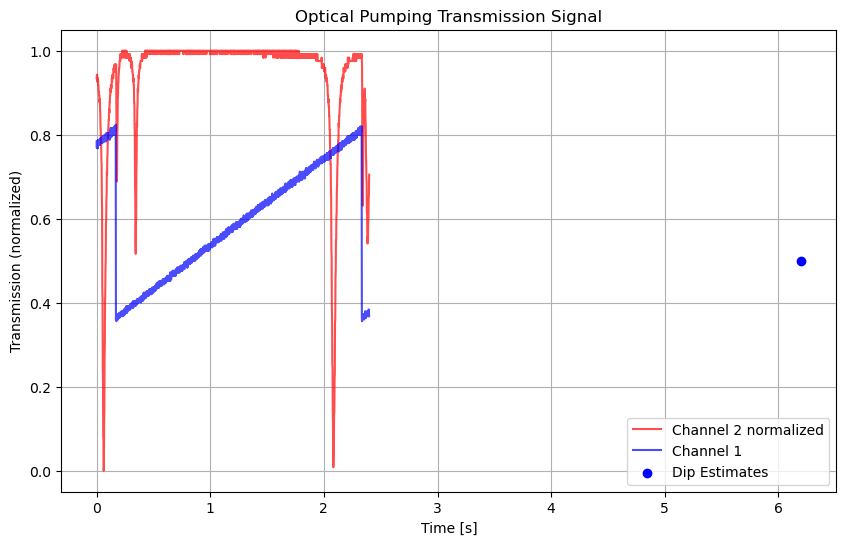

In [152]:
# connecting multiple files
freq = 335

t0 = 0.15
x0s = np.array([0.05,0.2,0])
savename = "5s measurement Mar 25 - " + str(freq) + 'kHz'
filename = "c2-335kHz_24mV"

nCut = (t0 // (time[1] - time[0])).astype(int)
time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 25 measurement/' +filename+ '.csv')

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

# nCut = (t0 // (time[1] - time[0])).astype(int)
# time_cutFirst = time[nCut:] - t0
# y2_norm_cutFirst = y2_norm[nCut:]
# plt.figure(figsize=(10, 6))
# plt.plot(time, y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)
# plt.plot(time, y1, label='Channel 1', color='blue', alpha=0.7)
# plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')
#
# # Labels and formatting
# plt.xlabel('Time [s]')
# plt.ylabel('Transmission (normalized)')
# plt.title('Optical Pumping Transmission Signal')
# plt.legend(loc="lower right")
# plt.grid(True)
# plt.savefig("figures/" + savename, dpi=300)
#
# plt.show()

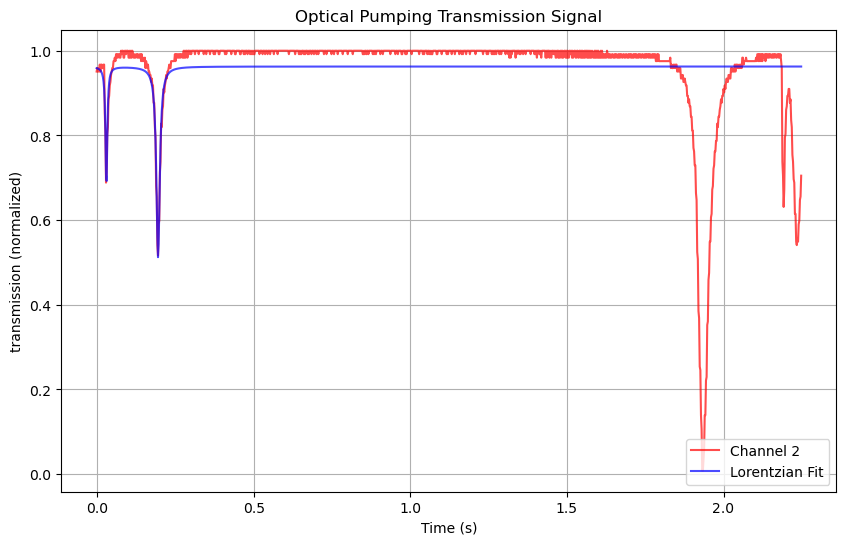

In [138]:
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1])
lower_bound = (0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.double_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.double_lorentz, "fit to " + savename)

In [143]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))


dV = (v_0 - v_1)
# dV = ufloat(dV.n, dV.s/10) # faking 10x more certain data TODO: comment this out
print(f"dV: {dV:.2ue}")

dV: (5.66+/-0.21)e-01


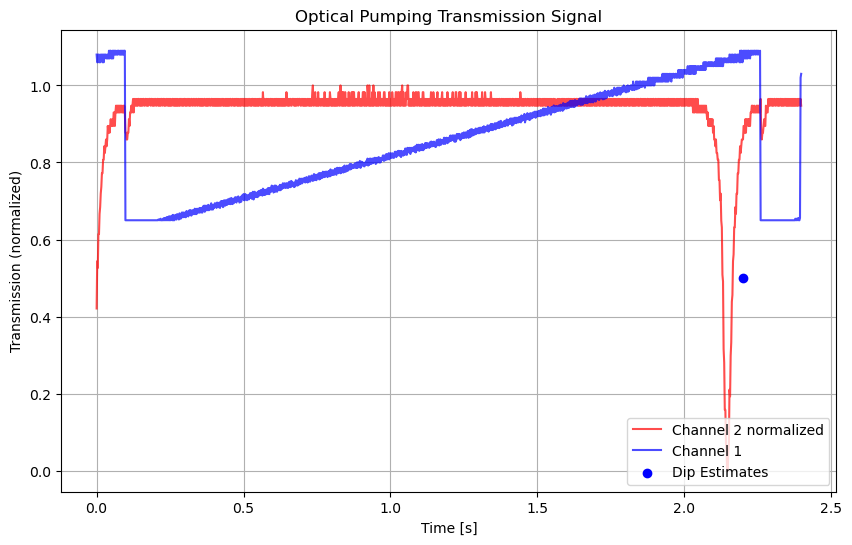

In [153]:

t0 = 0
x0 =  2.2
savename = "5s measurement Mar 25 - " + str(freq) + 'kHz'
filename = "c1-335kHz_0mV"


time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 25 measurement/' +filename+ '.csv')

nCut = (t0 // (time[1] - time[0])).astype(int)
time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]
plt.figure(figsize=(10, 6))
plt.plot(time, y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)
plt.plot(time, y1, label='Channel 1', color='blue', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()


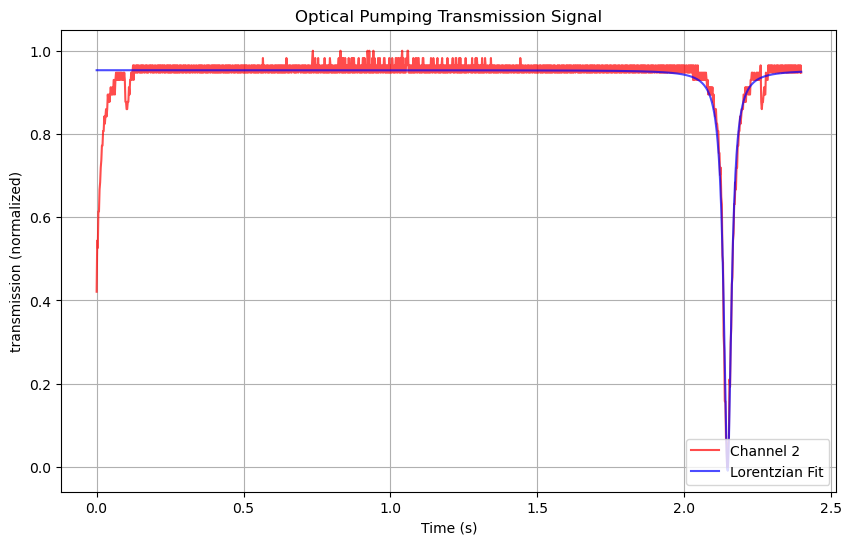

In [145]:
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [146]:
x0_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x0_index = int(x0_u.n // dt)

numAvg = 10

v_0 = ufloat(np.mean(y1[x0_index - numAvg : x0_index + numAvg]),
             np.std(y1[x0_index - numAvg : x0_index + numAvg]))
print(f"v_0: {v_0:.2ue}")

v_0: (1.0655+/-0.0097)e+00


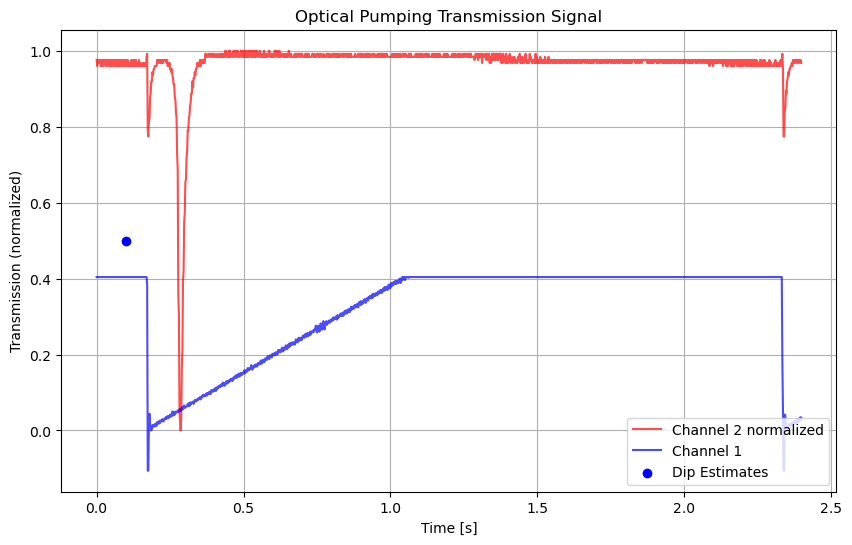

In [155]:
t0 = 0
x0 =  0.1
vHoriz = ufloat(50,0.05) / 1000
savename = "5s measurement Mar 25 - " + str(freq) + 'kHz'
filename = "c3-335kHz_50mV"

time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 25 measurement/' +filename+ '.csv')

nCut = (t0 // (time[1] - time[0])).astype(int)
time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

plt.figure(figsize=(10, 6))
plt.plot(time_cutFirst, y2_norm_cutFirst, label='Channel 2 normalized', color='red', alpha=0.7)
# plt.plot(time, y1, label='Channel 1', color='blue', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

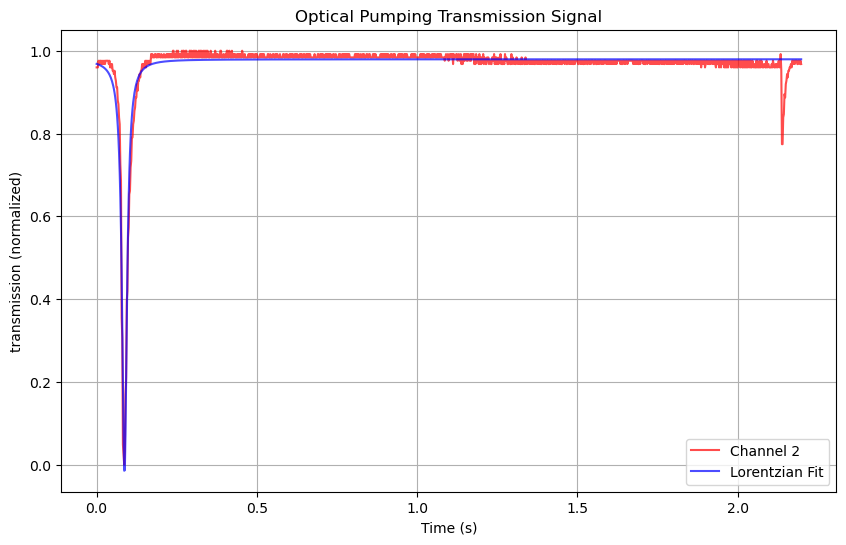

In [148]:
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [149]:
x1_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x1_index = int(x1_u.n // dt)

numAvg = 10

v_1 = ufloat(np.mean(y1[x1_index - numAvg : x1_index + numAvg]),
             np.std(y1[x1_index - numAvg : x1_index + numAvg]))
print(f"v_1: {v_1:.2ue}")

v_1: (5.47+/-0.59)e-02


In [128]:
print(f"(v_0 - v_1) + 2*dV: {(v_0 - v_1) + 2*dV:.2ue}")
m.append_to_Vcalibration((v_0 - v_1) + 2*dV,vHoriz,"models/VtoVcalibration.csv")

(v_0 - v_1) + 2*dV: (1.73+/-0.41)e+00
Attempting to write to models/VtoVcalibration.csv...
write completed
function returning


### Fitting Conversion Value

In [16]:
savename = "VtoV calibration graph"
df = pd.read_csv('./models/VtoVcalibration.csv', skiprows=2,
                 usecols=[0,1,2,3], names=['Vsweep', 'uVsweep', 'Vhoriz', 'uVhoriz'])


Vsweep = np.array(df['Vsweep'].values)
uVsweep = np.array(df['uVsweep'].values)
Vhoriz = np.array(df['Vhoriz'].values)
uVhoriz = np.array(df['uVhoriz'].values)

quad_model = odr.Model(linear_wInt)

my_data = odr.RealData(Vhoriz, Vsweep, sy=uVsweep, sx=uVhoriz)

p0 = [1,1]
my_odr = odr.ODR(my_data, quad_model, beta0=p0)

output = my_odr.run()

VsweepToHoriz = ufloat(output.beta[0],output.sd_beta[0])
intercept = ufloat(output.beta[1],output.sd_beta[1])

print("with intercept")
print(f"VsweepToHoriz: {VsweepToHoriz:.2ue}")
print(f"intercept: {intercept:.2ue}")
VToBhoriz = VsweepToHoriz * VtoB
print(f"VToBhoriz: {VToBhoriz:.2ue}")


quad_model = odr.Model(linear_0intercept)

my_data = odr.RealData(Vhoriz, Vsweep, sy=uVsweep, sx=uVhoriz)

p0 = [1]
my_odr = odr.ODR(my_data, quad_model, beta0=p0)

output = my_odr.run()

VsweepToHoriz = ufloat(output.beta[0],output.sd_beta[0])

print("without intercept")
print(f"VsweepToHoriz: {VsweepToHoriz:.2ue}")
VToBhoriz = VsweepToHoriz * VtoB
print(f"VToBhoriz: {VToBhoriz:.2ue}")

with intercept
VsweepToHoriz: (2.796+/-0.010)e+01
intercept: (-5.6+/-2.4)e-03
VToBhoriz: (1.735+/-0.012)e-03
without intercept
VsweepToHoriz: (2.7731+/-0.0047)e+01
VToBhoriz: (1.721+/-0.010)e-03


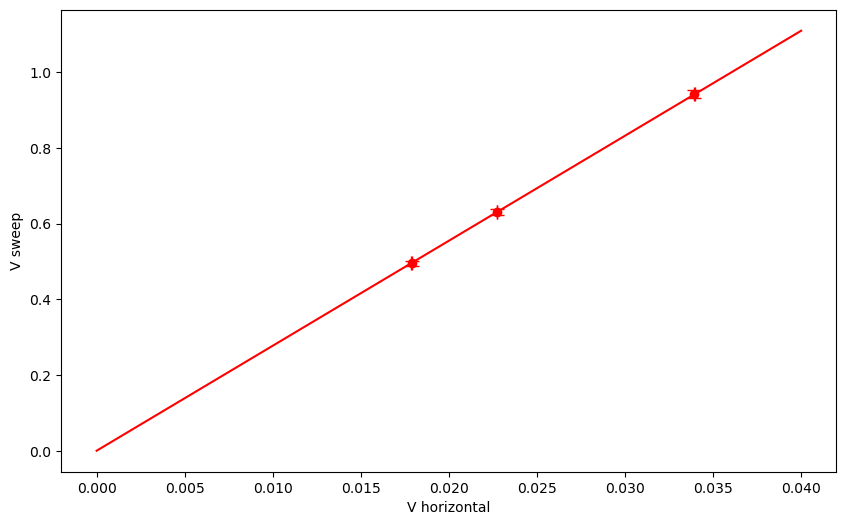

In [17]:
xFullAxis = np.linspace(0,0.04)

plt.figure(figsize=(10, 6))
plt.errorbar(Vhoriz, Vsweep, yerr=uVsweep, xerr=uVhoriz, capsize=5, label='V relationship data', fmt='o', color='red')
plt.plot(xFullAxis, linear([VsweepToHoriz.n], xFullAxis), label='relationship fit', color='red')
plt.ylabel('V sweep')
plt.xlabel('V horizontal')
plt.savefig("figures/" + savename, dpi=300)